In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, AveragePooling2D
from keras.datasets import mnist

## IN ORIGINAL LENET5 THERE WAS NO ACTIVATION FUNCTION IN ANY OF THE CONVOLUTION LAYER, ONLY THE FINAL LAYER OUTPUT LAYER USED SOFTMAX FOR CLASSIFICATION.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Add channel dimension + padding
X_train = tf.pad(
    X_train[..., tf.newaxis],
    [[0, 0], [2, 2], [2, 2], [0, 0]]
)

X_test = tf.pad(
    X_test[..., tf.newaxis],
    [[0, 0], [2, 2], [2, 2], [0, 0]]
)

# Normalize pixels: 0-255 → 0-1
X_train = tf.cast(X_train, tf.float32) / 255.0
X_test = tf.cast(X_test, tf.float32) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1790224879.775062      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790224879.777789      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
print(X_train.shape)
print(tf.reduce_min(X_train))
print(tf.reduce_max(X_train))

(60000, 32, 32, 1)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(1.0, shape=(), dtype=float32)


In [4]:
model = Sequential()

model.add(Conv2D(
    6,
    kernel_size=(5,5),
    strides=1,
    activation='tanh',
    input_shape=(32,32,1)
))

model.add(AveragePooling2D(
    pool_size=(2,2),
    strides=2
))

model.add(Conv2D(
    16,
    kernel_size=(5,5),
    strides=1,
    activation='tanh'
))

model.add(AveragePooling2D(
    pool_size=(2,2),
    strides=2
))

model.add(Conv2D(
    120,
    kernel_size=(5,5),
    strides=1,
    activation='tanh'
))

model.add(Flatten())

model.add(Dense(84, activation='tanh'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, batch_size = 128, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
 64/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2325 - loss: 2.2644

I0000 00:00:1790224884.312250      67 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6640 - loss: 1.3423 - val_accuracy: 0.8556 - val_loss: 0.6213
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8727 - loss: 0.5036 - val_accuracy: 0.8961 - val_loss: 0.4075
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8949 - loss: 0.3834 - val_accuracy: 0.9078 - val_loss: 0.3387
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9056 - loss: 0.3322 - val_accuracy: 0.9156 - val_loss: 0.3007
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9139 - loss: 0.2990 - val_accuracy: 0.9231 - val_loss: 0.2730
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9208 - loss: 0.2735 - val_accuracy: 0.9278 - val_loss: 0.2498
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9265 - loss: 0.2523 - val_accuracy: 0.9331 - val_loss: 0.2311
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9315 - loss: 0.2339 - val_accuracy: 0.9377 - val_

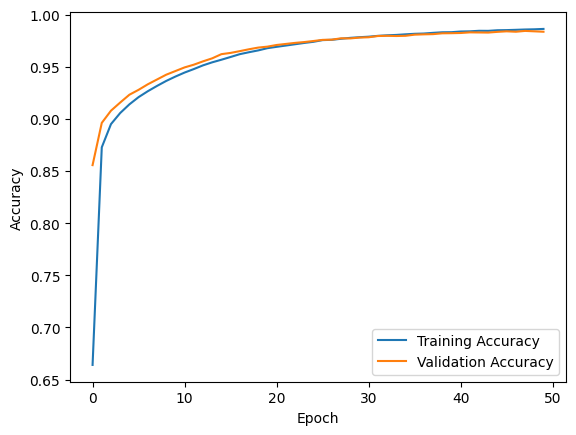

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

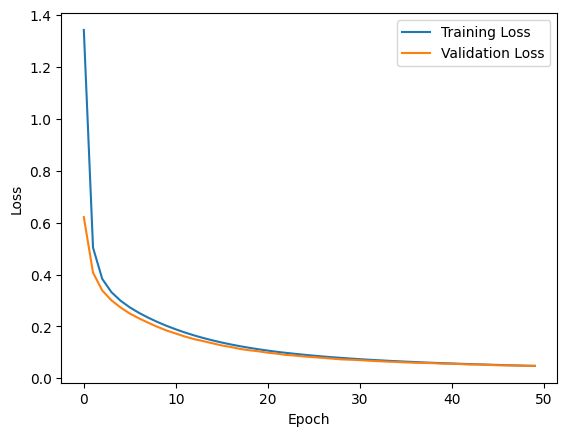

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()